# Bitcoin Sentiment Analysis - Exploratory Notebook
## Author: Boris Letić (Student 1)
## Date: 2025-02-13

This notebook demonstrates:
1. Data loading and exploration
2. Tweet preprocessing
3. BERT fine-tuning workflow
4. VADER baseline comparison
5. Sentiment feature engineering

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Imports successful")

✓ Imports successful


## 1. Load and Explore Data

In [ ]:
# Load raw tweets 
# tweets_df = pd.read_csv('../data/tweets_raw.csv')


sample_tweets = [
    "Bitcoin to the moon! 🚀 #BTC #bullish",
    "Crypto market crashing, panic selling everywhere 😱",
    "BTC holding steady at 45k, sideways movement",
    "Just bought more Bitcoin! HODL 💎🙌",
    "Warning: Bitcoin bubble about to burst!",
    "Neutral update: BTC volume increasing slightly"
]

tweets_df = pd.DataFrame({
    'datetime': pd.date_range('2024-01-01', periods=6, freq='h'),
    'text': sample_tweets,
    'likes': [150, 80, 30, 200, 90, 20],
    'retweets': [50, 30, 10, 80, 40, 5]
})

print(f"Loaded {len(tweets_df)} tweets")
tweets_df.head()

Loaded 6 tweets


,datetime,text,likes,retweets
0,2024-01-01 00:00:00,Bitcoin to the moon! 🚀 #BTC #bullish,150,50
1,2024-01-01 01:00:00,"Crypto market crashing, panic selling everywhe...",80,30
2,2024-01-01 02:00:00,"BTC holding steady at 45k, sideways movement",30,10
3,2024-01-01 03:00:00,Just bought more Bitcoin! HODL 💎🙌,200,80
4,2024-01-01 04:00:00,Warning: Bitcoin bubble about to burst!,90,40


In [4]:
# Basic statistics
print("Tweet Statistics:")
print(f"Date range: {tweets_df['datetime'].min()} to {tweets_df['datetime'].max()}")
print(f"Average likes: {tweets_df['likes'].mean():.2f}")
print(f"Average retweets: {tweets_df['retweets'].mean():.2f}")

Tweet Statistics:
Date range: 2024-01-01 00:00:00 to 2024-01-01 05:00:00
Average likes: 95.00
Average retweets: 35.83


## 2. Tweet Preprocessing

In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

def clean_tweet(text):
    """Clean tweet text"""
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#', '', text)
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
tweets_df['cleaned_text'] = tweets_df['text'].apply(clean_tweet)

print("Original vs Cleaned:")
for i in range(3):
    print(f"\nOriginal: {tweets_df.iloc[i]['text']}")
    print(f"Cleaned:  {tweets_df.iloc[i]['cleaned_text']}")

Original vs Cleaned:

Original: Bitcoin to the moon! 🚀 #BTC #bullish
Cleaned:  bitcoin to the moon btc bullish

Original: Crypto market crashing, panic selling everywhere 😱
Cleaned:  crypto market crashing panic selling everywhere

Original: BTC holding steady at 45k, sideways movement
Cleaned:  btc holding steady at k sideways movement


## 3. VADER Sentiment Analysis (Baseline)

In [6]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER
vader = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = vader.polarity_scores(text)
    compound = scores['compound']
    
    if compound >= 0.05:
        return 'positive', scores
    elif compound <= -0.05:
        return 'negative', scores
    else:
        return 'neutral', scores

# Apply VADER
tweets_df['vader_sentiment'] = tweets_df['text'].apply(lambda x: get_vader_sentiment(x)[0])
tweets_df['vader_scores'] = tweets_df['text'].apply(lambda x: get_vader_sentiment(x)[1])

# Display results
print("VADER Sentiment Analysis Results:")
print(tweets_df[['text', 'vader_sentiment', 'vader_scores']])

# Sentiment distribution
print("\nSentiment Distribution:")
print(tweets_df['vader_sentiment'].value_counts())

VADER Sentiment Analysis Results:
                                                text vader_sentiment  \
0               Bitcoin to the moon! 🚀 #BTC #bullish         neutral   
1  Crypto market crashing, panic selling everywhe...        negative   
2       BTC holding steady at 45k, sideways movement         neutral   
3                  Just bought more Bitcoin! HODL 💎🙌         neutral   
4            Warning: Bitcoin bubble about to burst!        negative   
5     Neutral update: BTC volume increasing slightly         neutral   

                                        vader_scores  
0  {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...  
1  {'neg': 0.565, 'neu': 0.435, 'pos': 0.0, 'comp...  
2  {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...  
3  {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...  
4  {'neg': 0.35, 'neu': 0.65, 'pos': 0.0, 'compou...  
5  {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...  

Sentiment Distribution:
vader_sentiment
neutral     4
negative    2
Name: c

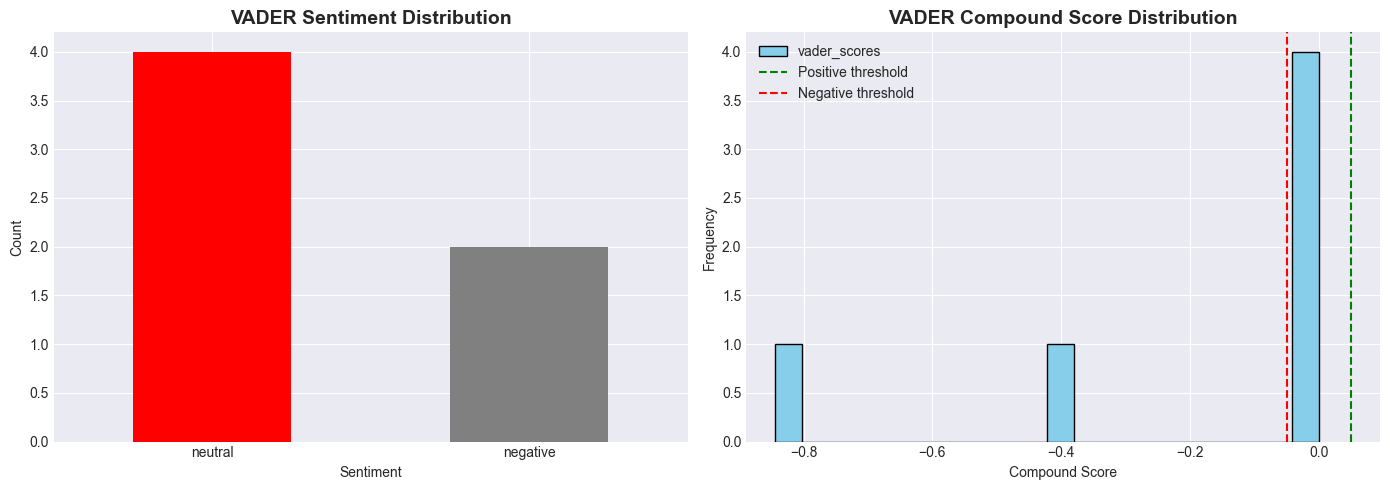

In [7]:
# Visualize sentiment distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment counts
tweets_df['vader_sentiment'].value_counts().plot(kind='bar', ax=ax[0], color=['red', 'gray', 'green'])
ax[0].set_title('VADER Sentiment Distribution', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Sentiment')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

# Compound scores
compound_scores = tweets_df['vader_scores'].apply(lambda x: x['compound'])
compound_scores.plot(kind='hist', bins=20, ax=ax[1], color='skyblue', edgecolor='black')
ax[1].axvline(x=0.05, color='green', linestyle='--', label='Positive threshold')
ax[1].axvline(x=-0.05, color='red', linestyle='--', label='Negative threshold')
ax[1].set_title('VADER Compound Score Distribution', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Compound Score')
ax[1].set_ylabel('Frequency')
ax[1].legend()

plt.tight_layout()
plt.show()

## 4. BERT Tokenization Preview

In [13]:
from transformers import BertTokenizer

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Example tokenization
sample_text = tweets_df.iloc[0]['cleaned_text']
print(f"Sample text: {sample_text}\n")

# Tokenize
encoding = tokenizer(
    sample_text,
    add_special_tokens=True,
    max_length=128,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)

print(f"Token IDs shape: {encoding['input_ids'].shape}")
print(f"Attention mask shape: {encoding['attention_mask'].shape}")
print(f"\nFirst 20 token IDs: {encoding['input_ids'][0][:20].tolist()}")
print(f"\nDecoded tokens: {tokenizer.convert_ids_to_tokens(encoding['input_ids'][0][:20])}")

Sample text: bitcoin to the moon btc bullish

Token IDs shape: torch.Size([1, 128])
Attention mask shape: torch.Size([1, 128])

First 20 token IDs: [101, 2978, 3597, 2378, 2000, 1996, 4231, 18411, 2278, 7087, 4509, 102, 0, 0, 0, 0, 0, 0, 0, 0]

Decoded tokens: ['[CLS]', 'bit', '##co', '##in', 'to', 'the', 'moon', 'bt', '##c', 'bull', '##ish', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


## 5. Sentiment Feature Engineering

In [14]:
# Calculate engagement score
tweets_df['engagement_score'] = (tweets_df['likes'] * 1.0) + (tweets_df['retweets'] * 2.0)

# Extract temporal features
tweets_df['hour'] = tweets_df['datetime'].dt.hour
tweets_df['day_of_week'] = tweets_df['datetime'].dt.dayofweek

# Sentiment encoding
sentiment_map = {'positive': 1.0, 'neutral': 0.0, 'negative': -1.0}
tweets_df['sentiment_score'] = tweets_df['vader_sentiment'].map(sentiment_map)

print("Engineered Features:")
print(tweets_df[['datetime', 'vader_sentiment', 'sentiment_score', 
                 'engagement_score', 'hour', 'day_of_week']])

Engineered Features:
             datetime vader_sentiment  sentiment_score  engagement_score  \
0 2024-01-01 00:00:00         neutral              0.0             250.0   
1 2024-01-01 01:00:00        negative             -1.0             140.0   
2 2024-01-01 02:00:00         neutral              0.0              50.0   
3 2024-01-01 03:00:00         neutral              0.0             360.0   
4 2024-01-01 04:00:00        negative             -1.0             170.0   
5 2024-01-01 05:00:00         neutral              0.0              30.0   

   hour  day_of_week  
0     0            0  
1     1            0  
2     2            0  
3     3            0  
4     4            0  
5     5            0  


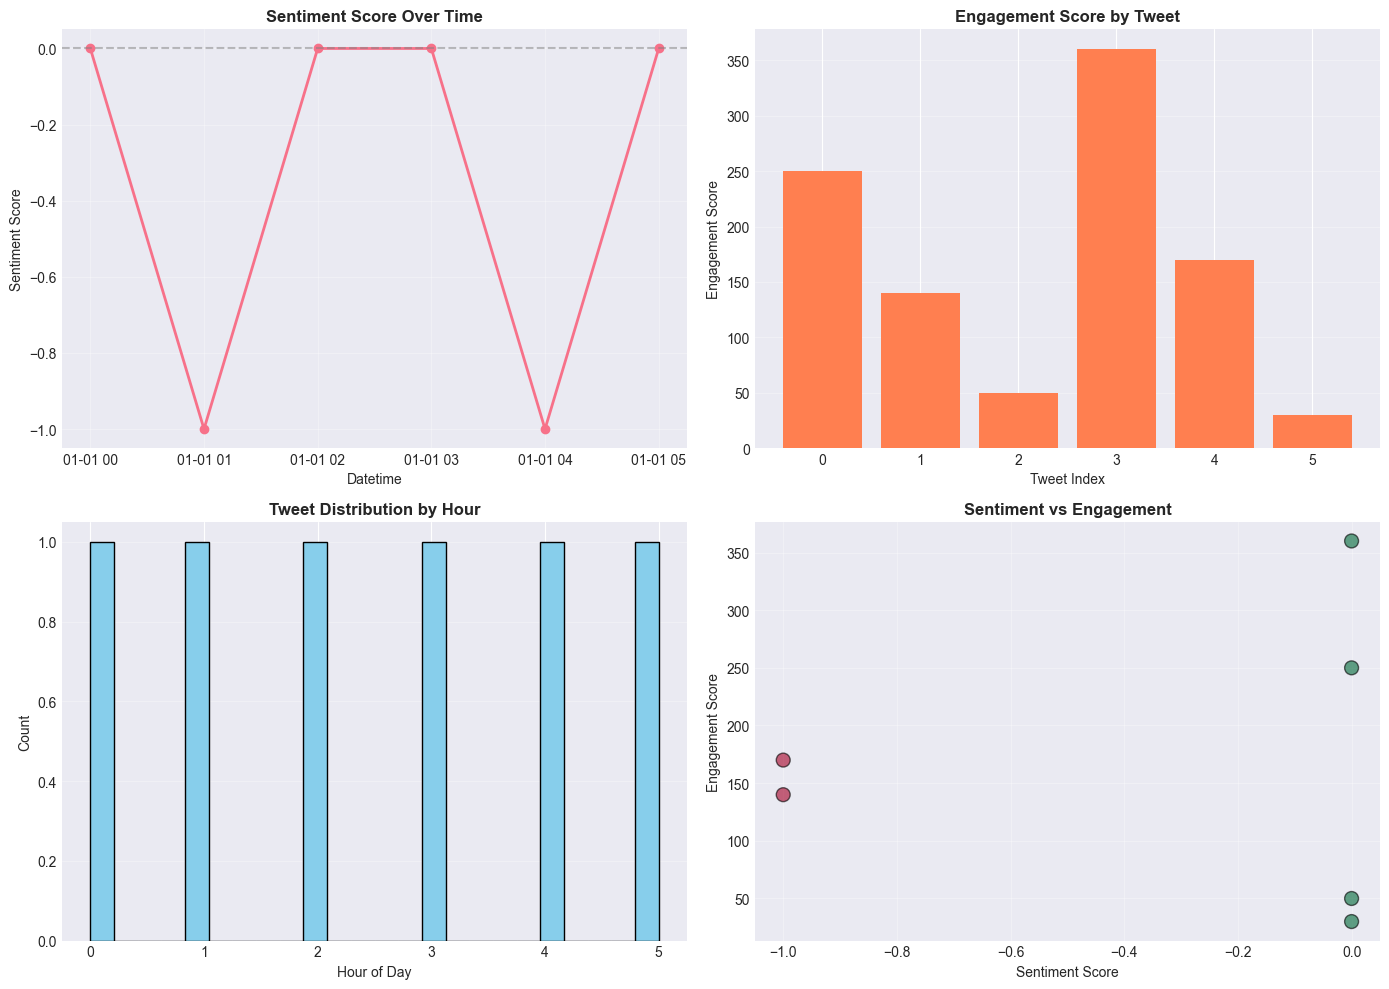

In [15]:
# Visualize features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sentiment score over time
axes[0, 0].plot(tweets_df['datetime'], tweets_df['sentiment_score'], marker='o', linewidth=2)
axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Sentiment Score Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Datetime')
axes[0, 0].set_ylabel('Sentiment Score')
axes[0, 0].grid(True, alpha=0.3)

# Engagement score
axes[0, 1].bar(range(len(tweets_df)), tweets_df['engagement_score'], color='coral')
axes[0, 1].set_title('Engagement Score by Tweet', fontweight='bold')
axes[0, 1].set_xlabel('Tweet Index')
axes[0, 1].set_ylabel('Engagement Score')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Hour distribution
axes[1, 0].hist(tweets_df['hour'], bins=24, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Tweet Distribution by Hour', fontweight='bold')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Sentiment vs Engagement
axes[1, 1].scatter(tweets_df['sentiment_score'], tweets_df['engagement_score'], 
                   s=100, alpha=0.6, c=tweets_df['sentiment_score'], 
                   cmap='RdYlGn', edgecolors='black')
axes[1, 1].set_title('Sentiment vs Engagement', fontweight='bold')
axes[1, 1].set_xlabel('Sentiment Score')
axes[1, 1].set_ylabel('Engagement Score')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()